In [1]:
import joblib
import numpy as np

# Load saved EEG-BIS dataset
data = joblib.load('data_10_sec_200.pkl')

x = data['x']  # Shape: (N, 1280)
y = data['y']  # Shape: (N,)
c = data['c']  # Shape: (N,), case IDs



print("Original shape:", x.shape)


valid_mask = ~np.isnan(x).any(axis=1)


x_clean = x[valid_mask]
y_clean = y[valid_mask]
c_clean = c[valid_mask]

print("Cleaned shape:", x_clean.shape)
print("NaNs remaining:", np.isnan(x_clean).sum())


x = x_clean
y = y_clean
c = c_clean



# Print basic info
print(f"EEG segments shape: {x.shape}")
print(f"BIS labels shape: {y.shape}")
print(f"Case ID shape: {c.shape}")


Original shape: (908642, 1280)
Cleaned shape: (906929, 1280)
NaNs remaining: 0
EEG segments shape: (906929, 1280)
BIS labels shape: (906929,)
Case ID shape: (906929,)


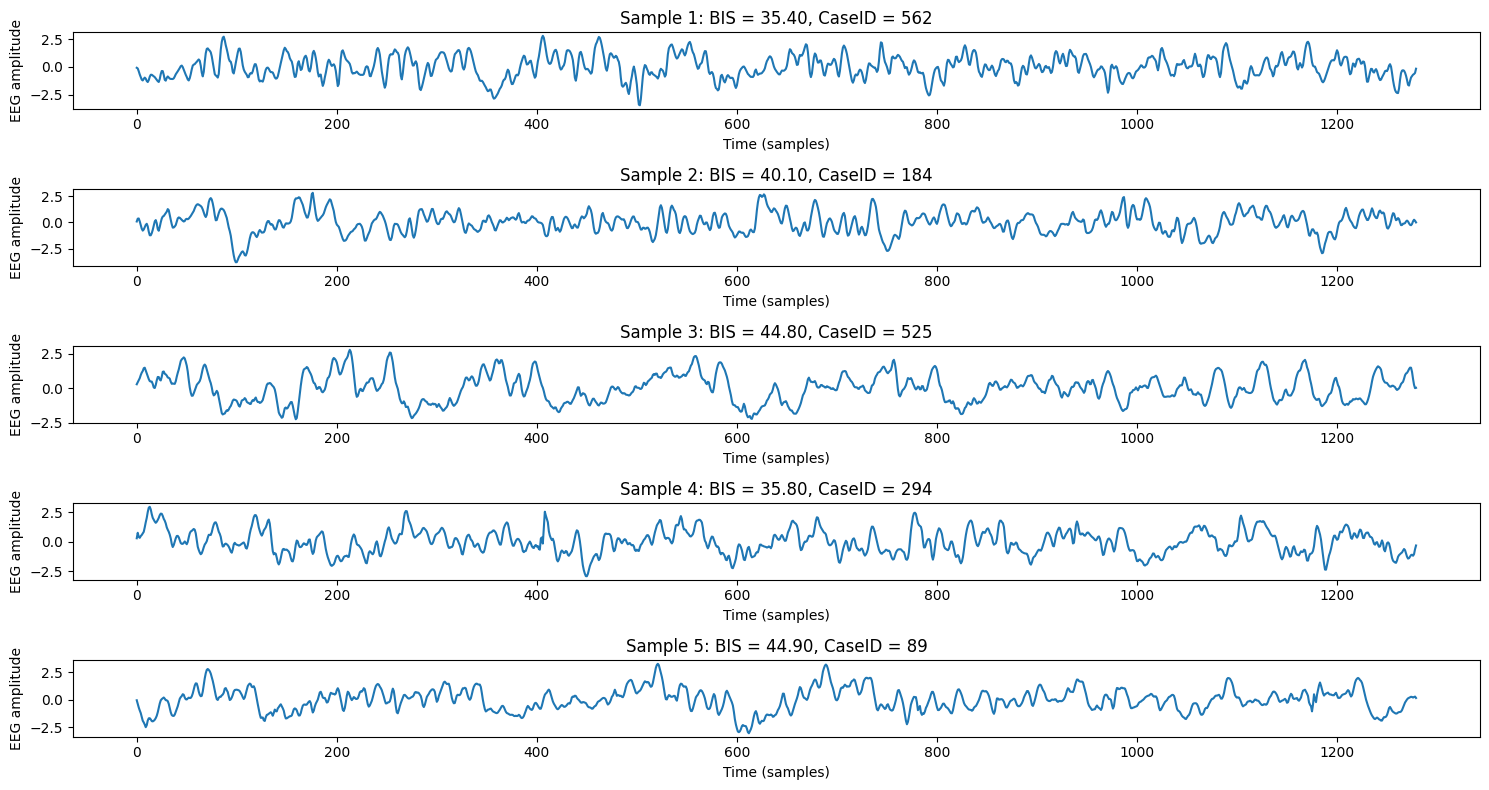

In [2]:
import matplotlib.pyplot as plt

# Plot a few random EEG segments with BIS values
num_samples = 5
indices = np.random.choice(len(x), size=num_samples, replace=False)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(indices):
    plt.subplot(num_samples, 1, i + 1)
    plt.plot(x[idx])
    plt.title(f"Sample {i+1}: BIS = {y[idx]:.2f}, CaseID = {c[idx]}")
    plt.xlabel('Time (samples)')
    plt.ylabel('EEG amplitude')
    plt.tight_layout()
plt.show()


# Group Samples by Subject (CaseID)

In [3]:
import numpy as np
import pandas as pd
from collections import defaultdict

# Create a dataframe to work easily
df = pd.DataFrame({
    'caseid': c,
    'bis': y
})

# Group sample indices by caseid
caseid_to_indices = defaultdict(list)
for idx, cid in enumerate(c):
    caseid_to_indices[cid].append(idx)

print(f"Total unique subjects (caseids): {len(caseid_to_indices)}")


Total unique subjects (caseids): 200


# Compute BIS Stats Per Subject

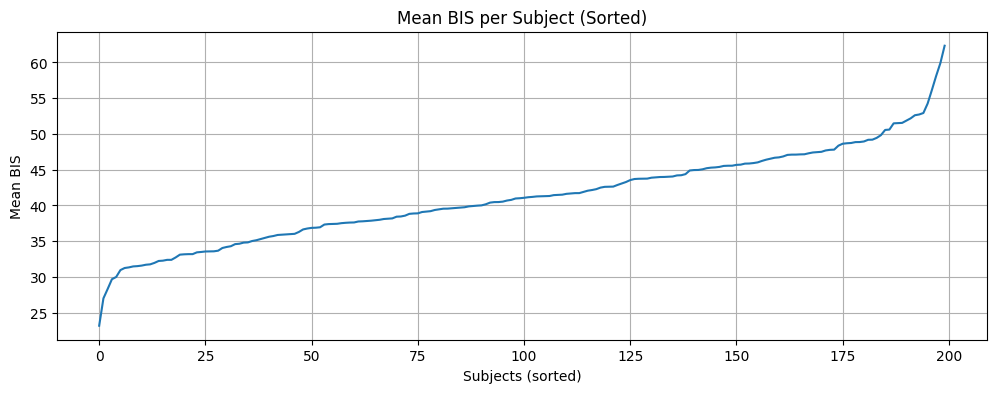

In [4]:
# Compute BIS stats for each subject
case_stats = []
for cid, indices in caseid_to_indices.items():
    bis_vals = y[indices]
    case_stats.append({
        'caseid': cid,
        'min_bis': np.min(bis_vals),
        'max_bis': np.max(bis_vals),
        'mean_bis': np.mean(bis_vals),
        'count': len(bis_vals)
    })

df_stats = pd.DataFrame(case_stats)
df_stats.sort_values(by='mean_bis', inplace=True)

# Optional: visualize BIS distribution across subjects
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(df_stats['mean_bis'].values)
plt.title("Mean BIS per Subject (Sorted)")
plt.xlabel("Subjects (sorted)")
plt.ylabel("Mean BIS")
plt.grid(True)
plt.show()


# Select Test Subjects with Diverse BIS Coverage

In [5]:
print("Subjects with mean BIS < 40:", (df_stats['mean_bis'] < 40).sum())
print("Subjects with mean BIS 40–60:", ((df_stats['mean_bis'] >= 40) & (df_stats['mean_bis'] <= 60)).sum())
print("Subjects with mean BIS > 60:", (df_stats['mean_bis'] > 60).sum())


Subjects with mean BIS < 40: 90
Subjects with mean BIS 40–60: 109
Subjects with mean BIS > 60: 1


In [6]:
# Split subject pools
low_pool  = df_stats[df_stats['mean_bis'] < 40]
mid_pool  = df_stats[(df_stats['mean_bis'] >= 40) & (df_stats['mean_bis'] <= 60)]
high_pool = df_stats[df_stats['mean_bis'] > 60]

# How many to select
low_n, mid_n, high_n = 10, 10, min(1, len(high_pool))  # only 1 high-BIS subject

# Sample
low_bis  = low_pool.sample(low_n, random_state=42)
mid_bis  = mid_pool.sample(mid_n, random_state=42)
high_bis = high_pool.sample(high_n, random_state=42)

# Combine into test set
test_caseids = set(pd.concat([low_bis, mid_bis, high_bis])['caseid'])
train_caseids = set(caseid_to_indices.keys()) - test_caseids

print(f"Selected {len(test_caseids)} test subjects")
print(f"Remaining {len(train_caseids)} training subjects")


Selected 21 test subjects
Remaining 179 training subjects


In [7]:
# Get sample indices
train_indices = [idx for cid in train_caseids for idx in caseid_to_indices[cid]]
test_indices  = [idx for cid in test_caseids  for idx in caseid_to_indices[cid]]

# Split the data
x_train, y_train = x[train_indices], y[train_indices]
x_test, y_test   = x[test_indices], y[test_indices]

print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")


x_train shape: (806743, 1280), y_train shape: (806743,)
x_test shape: (100186, 1280), y_test shape: (100186,)


In [8]:
import torch
from torch.utils.data import Dataset

class EEGBISDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)  # shape: (N, 1280)
        self.y = torch.tensor(y, dtype=torch.float32)  # shape: (N,)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        # Add channel dimension for CNNs: (1280,) -> (1, 1280)
        eeg = self.x[idx].unsqueeze(0)  # (1, 1280)
        bis = self.y[idx]               # scalar
        return eeg, bis



In [9]:
train_dataset = EEGBISDataset(x_train, y_train)
test_dataset  = EEGBISDataset(x_test, y_test)


In [10]:
from torch.utils.data import DataLoader

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)


In [64]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UNet1D_BiLSTM(nn.Module):
    def __init__(self, input_channels=1, lstm_hidden_size=64):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock1D(input_channels, 32)
        self.pool1 = nn.MaxPool1d(2)

        self.enc2 = ConvBlock1D(32, 64)
        self.pool2 = nn.MaxPool1d(2)

        self.enc3 = ConvBlock1D(64, 128)
        self.pool3 = nn.MaxPool1d(2)

        self.enc4 = ConvBlock1D(128, 256)
        self.pool4 = nn.MaxPool1d(2)

        # Bottleneck BiLSTM
        self.bilstm = nn.LSTM(input_size=256, hidden_size=lstm_hidden_size, num_layers=1,
                              bidirectional=True, batch_first=True)

        # Decoder
        self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec1 = ConvBlock1D(2 * lstm_hidden_size + 256, 128)

        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec2 = ConvBlock1D(128 + 128, 64)

        self.up3 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec3 = ConvBlock1D(64 + 64, 32)

        self.up4 = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec4 = ConvBlock1D(32 + 32, 16)

        # Final regression layer
        self.final = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),   # Output shape: (B, 16, 1)
            nn.Flatten(),              # → (B, 16)
            nn.Linear(16, 1)           # → (B, 1)
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        pooled = self.pool4(e4)

        # BiLSTM expects (B, T, C) → input is (B, 256, time)
        lstm_in = pooled.permute(0, 2, 1)  # (B, T, C)
        lstm_out, _ = self.bilstm(lstm_in) # (B, T, 2*H)
        lstm_out = lstm_out.permute(0, 2, 1)  # (B, 2*H, T)

        # Decoder
        e4_resized = F.interpolate(e4, size=lstm_out.shape[-1])
        d1 = self.up1(torch.cat([lstm_out, e4_resized], dim=1))
        d1 = self.dec1(d1)
        
        e3_resized = F.interpolate(e3, size=d1.shape[-1])
        d2 = self.up2(torch.cat([d1, e3_resized], dim=1))
        d2 = self.dec2(d2)
        
        e2_resized = F.interpolate(e2, size=d2.shape[-1])
        d3 = self.up3(torch.cat([d2, e2_resized], dim=1))
        d3 = self.dec3(d3)
        
        e1_resized = F.interpolate(e1, size=d3.shape[-1])
        d4 = self.up4(torch.cat([d3, e1_resized], dim=1))
        d4 = self.dec4(d4)

        out = self.final(d4)
        return out.squeeze(1)  # (B,)
#_______________________________________________________________________________________________________________________________________________________________________________________________________________________________________

import torch
import torch.nn as nn
import torch.nn.functional as F

# Squeeze-and-Excitation block for 1D
class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, t = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

# Conv1D block with SE and Dropout
class ConvSEBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1, dropout_prob=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch, momentum=0.05),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch, momentum=0.05),
            nn.ReLU(inplace=True)
        )
        self.se = SEBlock1D(out_ch)
        self.dropout = nn.Dropout(p=dropout_prob)

    def forward(self, x):
        x = self.conv(x)
        x = self.se(x)
        x = self.dropout(x)
        return x

# Lightweight ConvLSTM-style module
class TemporalConvMemory(nn.Module):
    def __init__(self, channels, kernel_size=5):
        super().__init__()
        self.depthwise = nn.Conv1d(
            channels, channels, kernel_size=kernel_size,
            padding=kernel_size // 2, groups=channels
        )
        self.pointwise = nn.Conv1d(channels, channels, kernel_size=1)

    def forward(self, x):
        mem = self.depthwise(x)
        mem = F.relu(mem)
        mem = self.pointwise(mem)
        return mem + x

# Final optimized model
class LightUNet_SE_ConvLSTM(nn.Module):
    def __init__(self, input_channels=1, dropout_prob=0.2):
        super().__init__()
        # Encoder
        self.enc1 = ConvSEBlock1D(input_channels, 32, dropout_prob=dropout_prob)
        self.down1 = nn.Conv1d(32, 32, kernel_size=3, stride=2, padding=1)

        self.enc2 = ConvSEBlock1D(32, 64, dropout_prob=dropout_prob)
        self.down2 = nn.Conv1d(64, 64, kernel_size=3, stride=2, padding=1)

        self.enc3 = ConvSEBlock1D(64, 128, dropout_prob=dropout_prob)
        self.down3 = nn.Conv1d(128, 128, kernel_size=3, stride=2, padding=1)

        # Temporal memory (ConvLSTM-lite)
        self.temporal = TemporalConvMemory(128)

        # Decoder (channel corrections made here!)
        self.up3 = nn.ConvTranspose1d(128, 64, kernel_size=2, stride=2)
        self.dec3 = ConvSEBlock1D(192, 64, dropout_prob=dropout_prob)  # 64 (up) + 128 (skip)

        self.up2 = nn.ConvTranspose1d(64, 32, kernel_size=2, stride=2)
        self.dec2 = ConvSEBlock1D(96, 32, dropout_prob=dropout_prob)   # 32 (up) + 64 (skip)

        self.up1 = nn.ConvTranspose1d(32, 16, kernel_size=2, stride=2)
        self.dec1 = ConvSEBlock1D(48, 16, dropout_prob=dropout_prob)   # 16 (up) + 32 (skip)

        # Output
        self.out = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)       # (B, 32, T)
        d1 = self.down1(e1)     # (B, 32, T/2)

        e2 = self.enc2(d1)      # (B, 64, T/2)
        d2 = self.down2(e2)     # (B, 64, T/4)

        e3 = self.enc3(d2)      # (B, 128, T/4)
        d3 = self.down3(e3)     # (B, 128, T/8)

        # Bottleneck
        bottleneck = self.temporal(d3)  # (B, 128, T/8)

        # Decoder
        u3 = self.up3(bottleneck)
        u3 = F.interpolate(u3, size=e3.shape[-1])
        d3 = self.dec3(torch.cat([u3, e3], dim=1))

        u2 = self.up2(d3)
        u2 = F.interpolate(u2, size=e2.shape[-1])
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        u1 = F.interpolate(u1, size=e1.shape[-1])
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        return self.out(d1).squeeze(1)  # (B,)




In [49]:

#model = LightUNet_SE_ConvLSTM(input_channels=1)
#from torchinfo import summary
#summary(model)

In [65]:
model = UNet1D_BiLSTM(input_channels=1, lstm_hidden_size=64)
model = LightUNet_SE_ConvLSTM(input_channels=1)
'''print(model)

# Send to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)
model = model.to(device)
'''




device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet1D_BiLSTM(input_channels=1, lstm_hidden_size=64)
model = LightUNet_SE_ConvLSTM(input_channels=1, dropout_prob=0.2)

# If multiple GPUs are available, use DataParallel
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs with DataParallel...")
    model = nn.DataParallel(model)

# Send to device
model = model.to(device)

Using 2 GPUs with DataParallel...


In [66]:
from tqdm import tqdm

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    pbar = tqdm(dataloader, desc="Training", leave=False)

    for x_batch, y_batch in pbar:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_batch.size(0)
        pbar.set_postfix({'loss': loss.item()})

    return running_loss / len(dataloader.dataset)


def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    pbar = tqdm(dataloader, desc="Validating", leave=False)

    with torch.no_grad():
        for x_batch, y_batch in pbar:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            running_loss += loss.item() * x_batch.size(0)
            pbar.set_postfix({'val_loss': loss.item()})

    return running_loss / len(dataloader.dataset)




In [68]:
import datetime
import os

# Create logs folder if not exists
os.makedirs("logs", exist_ok=True)

# Create unique log file with timestamp
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
log_file_path = f"logs/experiment_{timestamp}.txt"

# Write header
with open(log_file_path, 'w') as f:
    f.write(f"Experiment Log - {timestamp}\n")
    f.write(f"{'-'*50}\n")



import time
import copy

# Hyperparameters
epochs = 20
lr = 1e-3
patience = 5  # early stopping
best_val_loss = float('inf')
patience_counter = 0

# Optimizer and loss
criterion = nn.L1Loss()  # or nn.MSELoss()
#optimizer = torch.optim.Adam(model.parameters(), lr=lr)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)



# Optional: scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

# For saving the best model
best_model_wts = copy.deepcopy(model.state_dict())

print("Traning Model: ", model)
for epoch in range(1, epochs + 1):
    start_time = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = validate(model, test_loader, criterion, device)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - start_time

    log_line = (
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"LR: {current_lr:.6f} | "
        f"Time: {epoch_time:.2f}s"
    )

    print(log_line)

    # Save to log file
    with open(log_file_path, 'a') as f:
        f.write(log_line + '\n')

    # Early stopping
    if val_loss < best_val_loss:
        bbest_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
    
        # Save the model state_dict
        model_save_path = f"logs/model_best.pt"
        torch.save(best_model_wts, model_save_path)
    
        # Log it
        with open(log_file_path, 'a') as f:
            f.write(f"Saved best model at epoch {epoch} → {model_save_path}\n")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

# Load best model weights
model.load_state_dict(best_model_wts)


Traning Model:  DataParallel(
  (module): LightUNet_SE_ConvLSTM(
    (enc1): ConvSEBlock1D(
      (conv): Sequential(
        (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.05, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (4): BatchNorm1d(32, eps=1e-05, momentum=0.05, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
      (se): SEBlock1D(
        (pool): AdaptiveAvgPool1d(output_size=1)
        (fc): Sequential(
          (0): Linear(in_features=32, out_features=4, bias=False)
          (1): ReLU(inplace=True)
          (2): Linear(in_features=4, out_features=32, bias=False)
          (3): Sigmoid()
        )
      )
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (down1): Conv1d(32, 32, kernel_size=(3,), stride=(2,), padding=(1,))
    (enc2): ConvSEBlock1D(
      (conv): Seq

Epoch 01 | Train Loss: 5.7405 | Val Loss: 3.4807 | LR: 0.001000 | Time: 1180.40s


Epoch 02 | Train Loss: 3.5559 | Val Loss: 4.4804 | LR: 0.001000 | Time: 1170.58s


Epoch 03 | Train Loss: 3.4347 | Val Loss: 3.5277 | LR: 0.001000 | Time: 1166.86s


Epoch 04 | Train Loss: 3.3427 | Val Loss: 3.6247 | LR: 0.000500 | Time: 1168.26s


...

Epoch 17 | Train Loss: 2.9552 | Val Loss: 3.3839 | LR: 0.000063 | Time: 1163.99s


Epoch 18 | Train Loss: 2.9356 | Val Loss: 3.3426 | LR: 0.000063 | Time: 1160.84s


Epoch 19 | Train Loss: 2.9337 | Val Loss: 3.3766 | LR: 0.000063 | Time: 1169.48s


Epoch 20 | Train Loss: 2.9280 | Val Loss: 3.3753 | LR: 0.000031 | Time: 1165.96s


<All keys matched successfully>

In [69]:
from collections import OrderedDict
import torch

# Step 1: Rebuild architecture
model = LightUNet_SE_ConvLSTM(input_channels=1)

# Step 2: Load and clean state_dict
checkpoint = torch.load("logs/model_best.pt")
new_state_dict = OrderedDict()

# Strip 'module.' prefix
for k, v in checkpoint.items():
    new_key = k.replace("module.", "")  # remove DataParallel prefix
    new_state_dict[new_key] = v

# Step 3: Load cleaned state_dict
model.load_state_dict(new_state_dict)

# Step 4: Send to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Step 5: Wrap in DataParallel *only if* using multi-GPU
if torch.cuda.device_count() > 1:
    model = torch.nn.DataParallel(model)

model.eval()


/tmp/ipykernel_518224/2832372915.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("logs/model_best.pt")


DataParallel(
  (module): LightUNet_SE_ConvLSTM(
    (enc1): ConvSEBlock1D(
      (conv): Sequential(
        (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.05, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (4): BatchNorm1d(32, eps=1e-05, momentum=0.05, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
      (se): SEBlock1D(
        (pool): AdaptiveAvgPool1d(output_size=1)
        (fc): Sequential(
          (0): Linear(in_features=32, out_features=4, bias=False)
          (1): ReLU(inplace=True)
          (2): Linear(in_features=4, out_features=32, bias=False)
          (3): Sigmoid()
        )
      )
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (down1): Conv1d(32, 32, kernel_size=(3,), stride=(2,), padding=(1,))
    (enc2): ConvSEBlock1D(
      (conv): Sequential(
       

In [70]:
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(model, train_loader, test_loader, device):
    model.eval()

    def get_predictions(dataloader):
        y_true_all, y_pred_all = [], []

        with torch.no_grad():
            for x_batch, y_batch in dataloader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                preds = model(x_batch)
                y_true_all.extend(y_batch.cpu().numpy())
                y_pred_all.extend(preds.cpu().numpy())

        return np.array(y_true_all), np.array(y_pred_all)

    # Train set evaluation
    y_train_true, y_train_pred = get_predictions(train_loader)
    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
    train_r2 = r2_score(y_train_true, y_train_pred)

    # Test set evaluation
    y_test_true, y_test_pred = get_predictions(test_loader)
    test_mae = mean_absolute_error(y_test_true, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
    test_r2 = r2_score(y_test_true, y_test_pred)

    # Error band (±10) accuracy
    band_accuracy = np.mean(np.abs(y_test_true - y_test_pred) <= 10) * 100

    # Print metrics
    print("\nEvaluation Summary:")
    print(f"Train MAE: {train_mae:.3f} | RMSE: {train_rmse:.3f} | R²: {train_r2:.3f}")
    print(f"Test  MAE: {test_mae:.3f} | RMSE: {test_rmse:.3f} | R²: {test_r2:.3f}")
    print(f"Test  ±10 BIS Accuracy: {band_accuracy:.2f}%")

    # -----------------------
    # Plot: Predicted vs Actual
    # -----------------------
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test_true, y_test_pred, alpha=0.3, label='Predicted vs Actual')
    plt.plot([0, 100], [0, 100], 'r--', label='Ideal')
    plt.xlabel('Actual BIS')
    plt.ylabel('Predicted BIS')
    plt.title('Predicted vs Actual BIS')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------
    # Bland–Altman Plot
    # -----------------------
    mean_vals = (y_test_true + y_test_pred) / 2
    diff_vals = y_test_pred - y_test_true
    mean_diff = np.mean(diff_vals)
    std_diff = np.std(diff_vals)
    loa_upper = mean_diff + 1.96 * std_diff
    loa_lower = mean_diff - 1.96 * std_diff

    plt.figure(figsize=(7, 4))
    plt.scatter(mean_vals, diff_vals, alpha=0.3)
    plt.axhline(mean_diff, color='red', linestyle='--', label='Mean Diff')
    plt.axhline(loa_upper, color='green', linestyle='--', label='Upper LoA')
    plt.axhline(loa_lower, color='green', linestyle='--', label='Lower LoA')
    plt.xlabel('Mean of Actual and Predicted BIS')
    plt.ylabel('Difference (Pred - Actual)')
    plt.title('Bland–Altman Plot')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        'train_mae': train_mae,
        'train_rmse': train_rmse,
        'train_r2': train_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2,
        'band_accuracy': band_accuracy,
    }



Evaluation Summary:
Train MAE: 2.855 | RMSE: 3.965 | R²: 0.786
Test  MAE: 3.375 | RMSE: 5.086 | R²: 0.669
Test  ±10 BIS Accuracy: 96.08%


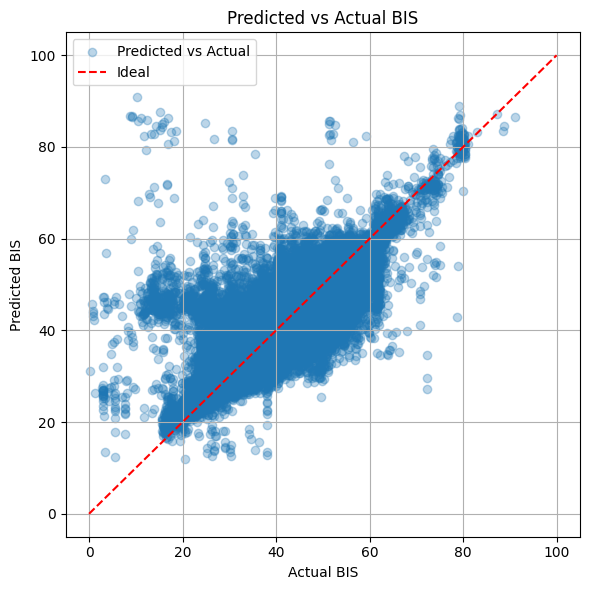

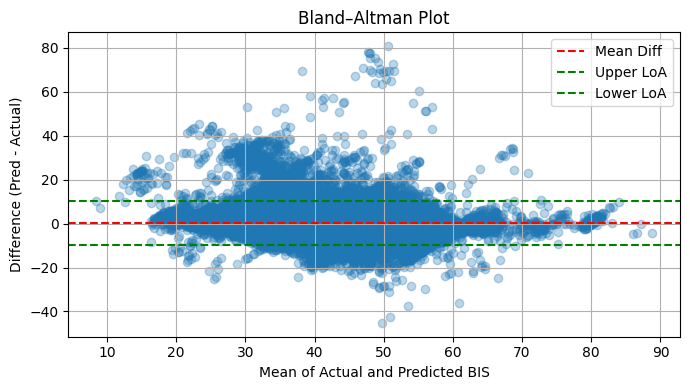

In [71]:
results = evaluate_model(model, train_loader, test_loader, device)


Evaluation Summary:
Train MAE: 3.299 | RMSE: 4.744 | R²: 0.693
Test  MAE: 3.502 | RMSE: 5.397 | R²: 0.627
Test  ±10 BIS Accuracy: 95.81%


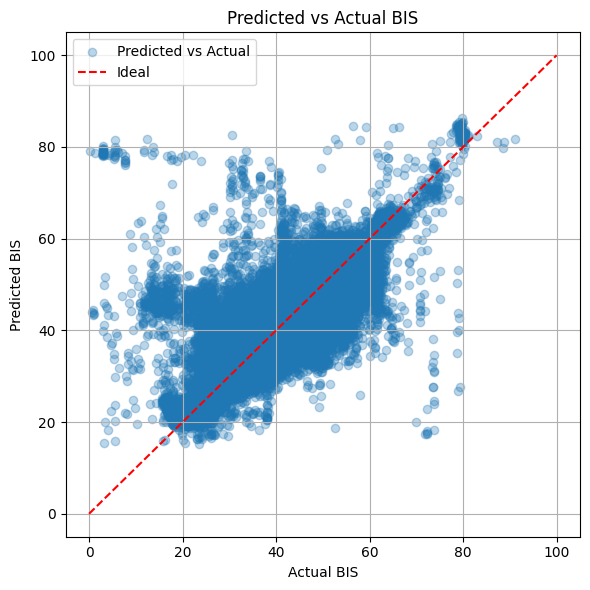

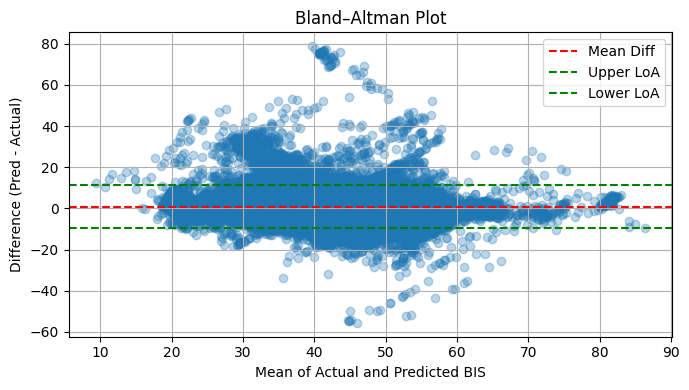

In [63]:
results = evaluate_model(model, train_loader, test_loader, device)


In [ ]:
results